# GPDF Dataset Inference

Fit GLM and GP posterior models to the generated Soay sheep IBM data. Recruitment is intercept-only, recruit size depends on maternal size, and sex probability is fixed outside inference.

In [ ]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS
from dl4bi_sps.kernels import rbf
import matplotlib.pyplot as plt

num_warmup = 1000
num_samples = 2500
num_chains = 2

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("gp_ibm_dataset.csv")
s_surv = df["z"].to_numpy()
y_surv = df["Surv"].to_numpy()

repr_data = df[["z", "Repr"]].dropna()
s_repr = repr_data["z"].to_numpy()
y_repr = repr_data["Repr"].to_numpy()

growth_data = df[["z", "z1"]].dropna()
s_growth = growth_data["z"].to_numpy()
y_growth = growth_data["z1"].to_numpy()

y_recr = df["Recr"].dropna().to_numpy()
rcsz_data = df[["z", "Rcsz"]].dropna()
s_rcsz = rcsz_data["z"].to_numpy()
y_rcsz = rcsz_data["Rcsz"].to_numpy()

print("Survival", len(y_surv))
print("Reproduction", len(y_repr))
print("Growth", len(y_growth))
print("Recruitment", len(y_recr)) 
print("Recruit Size", len(y_rcsz))

Survival 760
Reproduction 525
Growth 525
Recruitment 154
Recruit Size 139


In [13]:
df.head()

,z,Surv,z1,Repr,Sex,Recr,Rcsz,yr
0,2.574232,1,2.692836,0.0,NaN,NaN,NaN,1
1,2.350597,0,NaN,NaN,NaN,NaN,NaN,1
2,2.650646,0,NaN,NaN,NaN,NaN,NaN,1
3,2.569362,0,NaN,NaN,NaN,NaN,NaN,1
4,2.618475,1,2.904176,1.0,1.0,1.0,2.245276,1


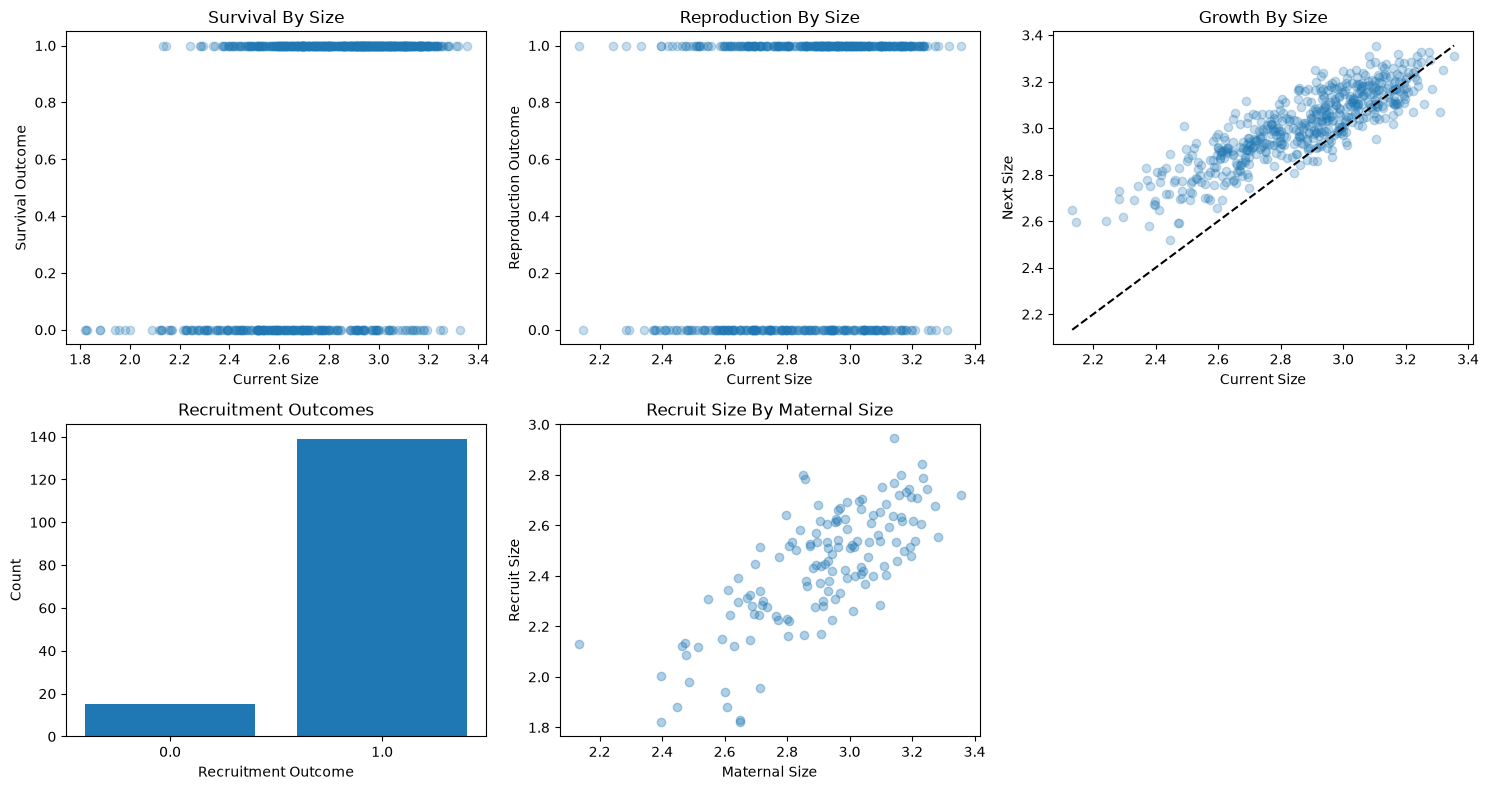

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].scatter(s_surv, y_surv, alpha=0.25)
axes[0, 0].set_title("Survival By Size")
axes[0, 0].set_xlabel("Current Size")
axes[0, 0].set_ylabel("Survival Outcome")

axes[0, 1].scatter(s_repr, y_repr, alpha=0.25)
axes[0, 1].set_title("Reproduction By Size")
axes[0, 1].set_xlabel("Current Size")
axes[0, 1].set_ylabel("Reproduction Outcome")

axes[0, 2].scatter(s_growth, y_growth, alpha=0.25)
axes[0, 2].plot([s_growth.min(), s_growth.max()], [s_growth.min(), s_growth.max()], linestyle="--", color="black")
axes[0, 2].set_title("Growth By Size")
axes[0, 2].set_xlabel("Current Size")
axes[0, 2].set_ylabel("Next Size")

values, counts = np.unique(y_recr, return_counts=True)
axes[1, 0].bar(values.astype(str), counts)
axes[1, 0].set_title("Recruitment Outcomes")
axes[1, 0].set_xlabel("Recruitment Outcome")
axes[1, 0].set_ylabel("Count")

axes[1, 1].scatter(s_rcsz, y_rcsz, alpha=0.35)
axes[1, 1].set_title("Recruit Size By Maternal Size")
axes[1, 1].set_xlabel("Maternal Size")
axes[1, 1].set_ylabel("Recruit Size")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

In [5]:
def linear_binary(s, y):
    intercept = numpyro.sample("int", dist.Normal(0, 5))
    slope = numpyro.sample("slope", dist.Normal(0, 5))
    numpyro.sample("y", dist.Bernoulli(logits=intercept + slope * s), obs=y)

def linear_gaussian(s, y):
    intercept = numpyro.sample("int", dist.Normal(0, 5))
    slope = numpyro.sample("slope", dist.Normal(0, 5))
    noise = numpyro.sample("noise", dist.HalfNormal(1))
    numpyro.sample("y", dist.Normal(intercept + slope * s, noise), obs=y)

def intercept_binary(y):
    intercept = numpyro.sample("int", dist.Normal(0, 5))
    numpyro.sample("y", dist.Bernoulli(logits=intercept), obs=y)

def gp_binary(s, y):
    intercept = numpyro.sample("int", dist.Normal(0, 5))
    var = numpyro.sample("var", dist.HalfNormal(2))
    ls = numpyro.sample("ls", dist.LogNormal(0, 1))
    latent = numpyro.sample("latent", dist.Normal(0, 1).expand([len(s)]).to_event(1))
    chol = jnp.linalg.cholesky(rbf(s, s, var, ls) + 5e-4 * jnp.eye(len(s)))
    mu = numpyro.deterministic("mu", chol @ latent + intercept)
    numpyro.sample("y", dist.Bernoulli(logits=mu), obs=y)

def gp_gaussian(s, y):
    intercept = numpyro.sample("int", dist.Normal(0, 5))
    var = numpyro.sample("var", dist.HalfNormal(2))
    ls = numpyro.sample("ls", dist.LogNormal(0, 1))
    noise = numpyro.sample("noise", dist.HalfNormal(1))
    latent = numpyro.sample("latent", dist.Normal(0, 1).expand([len(s)]).to_event(1))
    chol = jnp.linalg.cholesky(rbf(s, s, var, ls) + 5e-4 * jnp.eye(len(s)))
    mu = numpyro.deterministic("mu", chol @ latent + intercept)
    numpyro.sample("y", dist.Normal(mu, noise), obs=y)

def fit(model, key, **kwargs):
    mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
    mcmc.run(key, **kwargs)
    mcmc.print_summary(exclude_deterministic=True)
    return mcmc.get_samples()

In [6]:
rng = random.key(0)
keys = random.split(rng, 9)

In [7]:
surv_glm = fit(linear_binary, keys[0], s=s_surv, y=y_surv)
repr_glm = fit(linear_binary, keys[1], s=s_repr, y=y_repr)
growth_glm = fit(linear_gaussian, keys[2], s=s_growth, y=y_growth)
recr_samples = fit(intercept_binary, keys[3], y=y_recr)
rcsz_glm = fit(linear_gaussian, keys[4], s=s_rcsz, y=y_rcsz)

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
sample: 100%|██████████| 3500/3500 [00:01<00:00, 2728.26it/s, 7 steps of size 5.95e-02. acc. prob=0.95] 
/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -8.60      0.93     -8.61    -10.08     -7.08    592.23      1.00
     slope      3.41      0.34      3.42      2.86      3.96    595.82      1.00

Number of divergences: 0


sample: 100%|██████████| 3500/3500 [00:01<00:00, 2824.09it/s, 3 steps of size 5.59e-02. acc. prob=0.93] 
/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -5.04      1.09     -4.99     -6.82     -3.31    818.33      1.00
     slope      1.90      0.38      1.88      1.29      2.52    813.73      1.00

Number of divergences: 0


sample: 100%|██████████| 3500/3500 [00:01<00:00, 2610.87it/s, 7 steps of size 5.70e-02. acc. prob=0.94]  
/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      1.35      0.04      1.35      1.28      1.43   1445.73      1.00
     noise      0.08      0.00      0.08      0.08      0.08   1809.66      1.00
     slope      0.58      0.02      0.58      0.55      0.60   1446.95      1.00

Number of divergences: 0


sample: 100%|██████████| 3500/3500 [00:00<00:00, 7824.96it/s, 1 steps of size 9.21e-01. acc. prob=0.93]
/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      2.24      0.27      2.24      1.79      2.69   1736.85      1.00

Number of divergences: 0


sample: 100%|██████████| 3500/3500 [00:01<00:00, 2657.70it/s, 63 steps of size 5.32e-02. acc. prob=0.95] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      0.15      0.17      0.16     -0.14      0.42   1348.22      1.00
     noise      0.15      0.01      0.15      0.14      0.17   1560.41      1.00
     slope      0.78      0.06      0.78      0.69      0.88   1343.49      1.00

Number of divergences: 0


In [8]:
surv_gp = fit(gp_binary, keys[5], s=s_surv, y=y_surv)

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
sample: 100%|██████████| 3500/3500 [46:19<00:00,  1.26it/s, 127 steps of size 4.45e-02. acc. prob=0.95] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
        int     -0.27      1.34     -0.22     -2.55      1.86   5717.60      1.00
  latent[0]      0.28      0.79      0.27     -1.05      1.54   6311.65      1.00
  latent[1]     -2.01      0.63     -1.99     -3.00     -0.96   4812.92      1.00
  latent[2]      0.13      0.84      0.12     -1.26      1.51   8777.87      1.00
  latent[3]      0.02      0.98      0.03     -1.56      1.64  12925.79      1.00
  latent[4]      0.00      0.97     -0.01     -1.59      1.61  12874.05      1.00
  latent[5]      0.11      1.04      0.10     -1.65      1.77  10239.54      1.00
  latent[6]      0.16      0.97      0.14     -1.40      1.79  12270.87      1.00
  latent[7]     -0.45      1.01     -0.44     -2.14      1.15  10633.19      1.00
  latent[8]     -0.03      1.01     -0.02     -1.76      1.56  11477.73      1.00
  latent[9]      0.00      0.98     -0.01     -1.57      1.65  14179.38      1.00
 latent[10]    

In [9]:
repr_gp = fit(gp_binary, keys[6], s=s_repr, y=y_repr)

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
sample: 100%|██████████| 3500/3500 [15:08<00:00,  3.85it/s, 127 steps of size 4.94e-02. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
        int      0.34      1.17      0.32     -1.54      2.25   4262.83      1.00
  latent[0]     -0.45      0.87     -0.46     -1.83      1.02   4829.17      1.00
  latent[1]      1.02      0.63      0.98      0.04      2.11   6120.11      1.00
  latent[2]      0.60      0.94      0.59     -0.81      2.27   7954.18      1.00
  latent[3]     -0.07      0.99     -0.07     -1.73      1.49   8360.34      1.00
  latent[4]      0.02      0.96      0.03     -1.50      1.65   7577.44      1.00
  latent[5]     -0.03      1.00     -0.03     -1.66      1.63   8046.99      1.00
  latent[6]     -0.07      1.01     -0.09     -1.69      1.63   7353.34      1.00
  latent[7]     -0.03      1.01     -0.04     -1.74      1.57   9218.86      1.00
  latent[8]      0.13      0.98      0.13     -1.47      1.77   9682.68      1.00
  latent[9]      0.30      0.93      0.31     -1.22      1.85   7918.34      1.00
 latent[10]    

In [10]:
growth_gp = fit(gp_gaussian, keys[7], s=s_growth, y=y_growth)

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
sample: 100%|██████████| 3500/3500 [2:27:58<00:00,  2.54s/it, 1023 steps of size 1.75e-03. acc. prob=0.92]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
        int      2.61      1.03      2.69      0.90      4.21    613.72      1.00
  latent[0]      0.14      0.80      0.13     -1.21      1.42    700.35      1.00
  latent[1]      1.01      0.77      1.00     -0.29      2.21   1012.93      1.00
  latent[2]      0.74      0.85      0.75     -0.67      2.11    970.60      1.00
  latent[3]      0.18      0.98      0.16     -1.52      1.68   1008.68      1.00
  latent[4]     -0.27      0.96     -0.26     -1.74      1.43   1329.21      1.00
  latent[5]     -0.23      0.97     -0.24     -1.72      1.46   1391.87      1.00
  latent[6]     -0.16      0.97     -0.15     -1.73      1.42   1177.96      1.00
  latent[7]     -0.07      0.94     -0.07     -1.64      1.45   1165.99      1.00
  latent[8]      0.27      0.94      0.27     -1.28      1.83   1016.45      1.01
  latent[9]      0.18      0.95      0.16     -1.34      1.72   1250.27      1.00
 latent[10]    

In [11]:
rcsz_gp = fit(gp_gaussian, keys[8], s=s_rcsz, y=y_rcsz)

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_62242/973730694.py:36: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(model), num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
sample: 100%|██████████| 3500/3500 [07:49<00:00,  7.46it/s, 511 steps of size 9.96e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
        int      2.33      0.97      2.34      0.69      3.90   2629.92      1.00
  latent[0]     -0.17      0.84     -0.18     -1.52      1.23   3308.08      1.00
  latent[1]     -1.02      0.52     -0.92     -1.81     -0.23   3257.39      1.00
  latent[2]      0.46      0.90      0.44     -1.00      1.92   6086.39      1.00
  latent[3]     -0.35      0.97     -0.35     -1.96      1.17  10769.19      1.00
  latent[4]      0.01      0.98      0.00     -1.63      1.61  14559.55      1.00
  latent[5]     -0.30      0.95     -0.29     -1.83      1.31  11983.24      1.00
  latent[6]     -0.09      0.87     -0.07     -1.53      1.30   5384.79      1.00
  latent[7]      0.25      0.99      0.26     -1.28      1.93  10224.24      1.00
  latent[8]      0.09      0.97      0.10     -1.41      1.78  11506.99      1.00
  latent[9]     -0.29      1.01     -0.28     -1.95      1.34  13520.91      1.00
 latent[10]    

In [ ]:
gpdf_glm_samples = {"surv_int": surv_glm["int"], 
               "surv_slope": surv_glm["slope"], 
               "repr_int": repr_glm["int"], 
               "repr_slope": repr_glm["slope"],
               "growth_int": growth_glm["int"], 
               "growth_slope": growth_glm["slope"], 
               "growth_noise": growth_glm["noise"], 
               "recr_int": recr_samples["int"], 
               "rcsz_int": rcsz_glm["int"], 
               "rcsz_slope": rcsz_glm["slope"], 
               "rcsz_noise": rcsz_glm["noise"]}

gpdf_gp_samples = {"surv_int": surv_gp["int"], 
              "surv_var": surv_gp["var"], 
              "surv_ls": surv_gp["ls"], 
              "surv_mu": surv_gp["mu"], 
              "surv_latent":surv_gp['latent'],

              "repr_int": repr_gp["int"], 
              "repr_var": repr_gp["var"], 
              "repr_ls": repr_gp["ls"], 
              "repr_mu": repr_gp["mu"], 
              "repr_latent":repr_gp['latent'],

              "growth_int": growth_gp["int"], 
              "growth_var": growth_gp["var"], 
              "growth_ls": growth_gp["ls"], 
              "growth_noise": growth_gp["noise"], 
              "growth_mu": growth_gp["mu"], 
              "growth_latent":growth_gp['latent'],

              "recr_int": recr_samples["int"], 

              "rcsz_int": rcsz_gp["int"], 

              "rcsz_var": rcsz_gp["var"], 
              "rcsz_ls": rcsz_gp["ls"], 
              "rcsz_noise": rcsz_gp["noise"], 
              "rcsz_mu": rcsz_gp["mu"],
              "rcsz_latent":rcsz_gp['latent']
        }

np.savez_compressed("gpdf_glm_samples.npz", **{name: np.asarray(jax.device_get(value)) for name, value in glm_samples.items()})
np.savez_compressed("gpdf_gp_samples.npz", **{name: np.asarray(jax.device_get(value)) for name, value in gp_samples.items()})